Upload content image


Saving content.jpg to content (1).jpg
Upload style image


Saving style.jpg to style (1).jpg


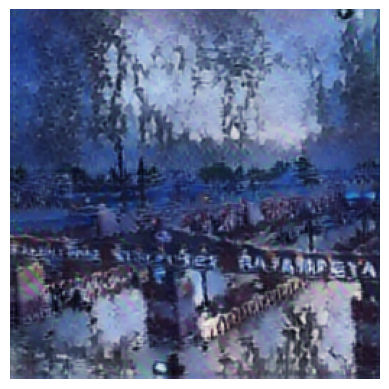

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
from google.colab import files
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image

print("Upload content image")
content_path = list(files.upload().keys())[0]

print("Upload style image")
style_path = list(files.upload().keys())[0]

def load_image(path):
    img = Image.open(path)
    img = np.array(img).astype(np.float32)/255.0
    img = tf.image.resize(img, (256,256))
    img = img[tf.newaxis, :]
    return img

content_image = load_image(content_path)
style_image = load_image(style_path)

model = hub.load(
'https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2'
)

stylized_image = model(
tf.constant(content_image),
tf.constant(style_image)
)[0]

plt.imshow(tf.squeeze(stylized_image))
plt.axis('off')
plt.show()